<a href="https://colab.research.google.com/github/rekhadhorigol/data-science-capstone-1/blob/main/Data_Science_Capstone_1_Rekha_Dhorigol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CAPSTONE PROJECT 1 DATA SCIENCE**
**Name: Rekha Dhorigol**

# Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
sns.set(style="whitegrid")


Imports essential libraries for data analysis and visualization.
1. numpy and pandas handle data
2. matplotlib and seaborn create plots
3. scipy.stats provides statistical functions
4. sns.set(style="whitegrid") makes plots clean & easy to read

# Load and Preview Data

In [ ]:
# Tab-delimited
male_df = pd.read_csv("nhanes_adult_male_bmx_2020.csv", comment="#")
female_df = pd.read_csv("nhanes_adult_female_bmx_2020.csv", comment="#")
with open("nhanes_adult_male_bmx_2020.csv") as f:
    for _ in range(5):
        print(f.readline())

# Body measurements of males >= 18 years old [cm]

#

# Weight (kg)

# Standing Height (cm)

# Upper Arm Length (cm)



1. Reads male & female adult NHANES datasets from CSV files into pandas DataFrames.
2. Comment="#" ignores lines starting with #, which are often metadata/notes in CSV.
3. Prints first 5 lines of the male dataset for a quick preview of the raw file structure.
4. Loading data into DataFrames makes it easier to manipulate and analyze.

# Preview DataFrames

In [ ]:
display(female_df.head())
display(male_df.head())

,BMXWT,BMXHT,BMXARML,BMXLEG,BMXARMC,BMXHIP,BMXWAIST
0,97.1,160.2,34.7,40.8,35.8,126.1,117.9
1,91.1,152.7,33.5,33.0,38.5,125.5,103.1
2,73.0,161.2,37.4,38.0,31.8,106.2,92.0
3,61.7,157.4,38.0,34.7,29.0,101.0,90.5
4,55.4,154.6,34.6,34.0,28.3,92.5,73.2


,BMXWT,BMXHT,BMXARML,BMXLEG,BMXARMC,BMXHIP,BMXWAIST
0,98.8,182.3,42.0,40.1,38.2,108.2,120.4
1,74.3,184.2,41.1,41.0,30.2,94.5,86.8
2,103.7,185.3,47.0,44.0,32.0,107.8,109.6
3,86.0,167.8,39.5,38.4,29.0,106.4,108.3
4,99.4,181.6,40.4,39.9,36.0,120.2,107.0


1. Display first 5 rows of the female and male datasets, respectively.
2. Inspecting first few rows helps verify that the data has been loaded correctly.

# Histograms of Weights

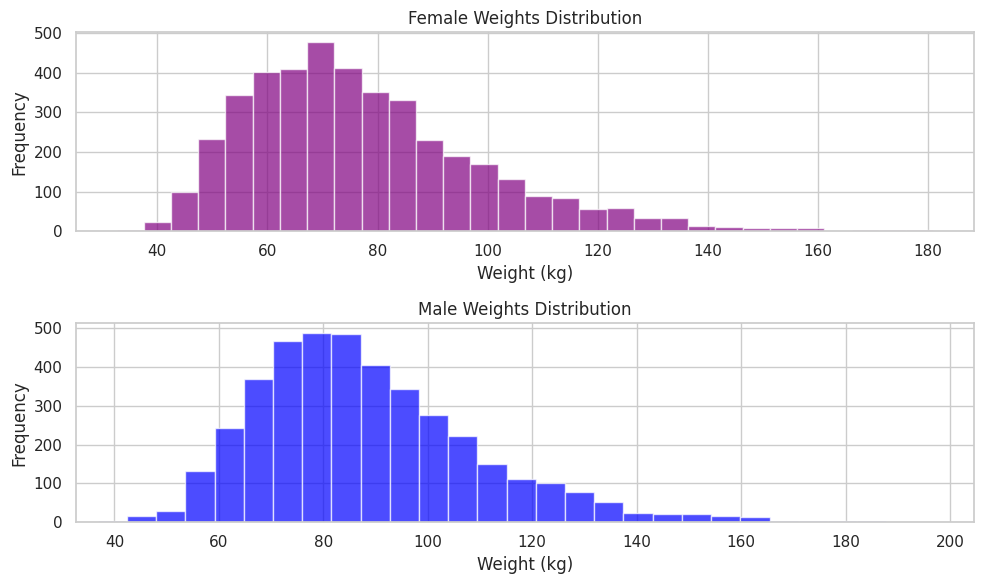

In [ ]:
plt.figure(figsize=(10,6))

# Female weights
plt.subplot(2,1,1)
plt.hist(female_df["BMXWT"], bins=30, color="purple", alpha=0.7)
plt.title("Female Weights Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

# Male weights
plt.subplot(2,1,2)
plt.hist(male_df["BMXWT"], bins=30, color="blue", alpha=0.7)
plt.title("Male Weights Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

# Match x-axis limits
xmin = min(female_df["BMXWT"].min(), male_df["BMXWT"].min())
xmax = max(male_df["BMXWT"].max(), female_df["BMXWT"].max())
plt.xlim(xmin, xmax)

plt.tight_layout()
plt.show()

***Explanation:***
1. Creates histograms to visualize the distribution of weights (BMXWT) for females and males.
2. Place female and male histograms in a 2-row layout.
3. bins=30 divides the weight range into 30 intervals.
4. plt.xlim(xmin, xmax) ensures both histograms use the same x-axis scale for easier comparison.
5. plt.tight_layout() avoids overlapping labels & plt.show() displays the plots.

***Insights:***
1. **Central Tendency:**
* Female: 60–70 kg.
* Male: 75–85 kg.

2. **Spread and Variability:**
* Male: More variability.
* Female: Slightly narrower distribution.

3. **Skewness:**
* Female: Slight right skew - few females have higher weights than average.
* Male: More symmetrically distributed, but could still have a slight right tail.

4. **Overlap:** Some overlapping observed between male and female weight distributions, but males generally weigh more on average.

5. **Outliers:** Any bars far away from main cluster = potential outliers (very low/very high weights).

# Boxplot Comparison of Weights

/tmp/ipython-input-1467541450.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_df["BMXWT"], male_df["BMXWT"]], labels=["Female", "Male"])


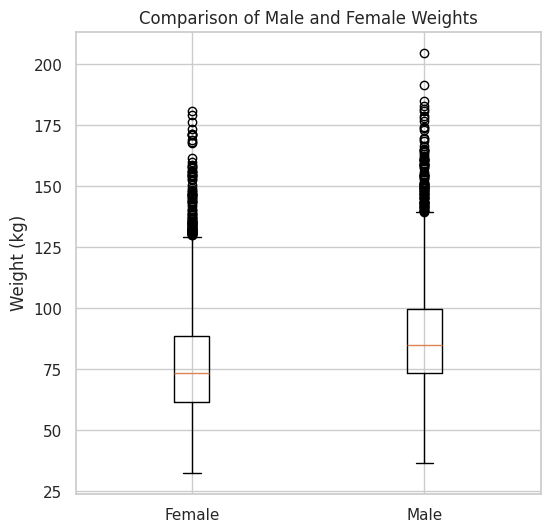

In [ ]:
plt.figure(figsize=(6,6))
plt.boxplot([female_df["BMXWT"], male_df["BMXWT"]], labels=["Female", "Male"])
plt.title("Comparison of Male and Female Weights")
plt.ylabel("Weight (kg)")
plt.show()


***Explanation:***
1. Creates boxplot to compare the distribution of weights (BMXWT) between females and males to visualize median, quartiles (Q1, Q3), range & potential outliers.
2. labels=["Female", "Male"] names the two boxes, and plt.ylabel("Weight (kg)") labels the y-axis.
3. * Median line - central tendency.
   * Height of box & whiskers - variability/spread.
   * Dots outside the whiskers - outliers.
   * Position of median within the box - skewness.

***Insights:***
1. **Median:** Male median > female median (generally) - males tend to weigh more.

2. **Spread and Variability:**
* Male box may be taller - wider range of weights.
* Female weights - slightly narrower spread.

3. **Outliers:** Points outside whiskers - outliers.

4. **Skewness Visualization:** If median is closer to the bottom or top of the box - skewness in distribution.


# Descriptive Statistics of Weights

In [ ]:
def describe(series):
    return {
        "Mean": series.mean(),
        "Median": series.median(),
        "Std Dev": series.std(),
        "Variance": series.var(),
        "Skewness": skew(series),
        "Kurtosis": kurtosis(series),
        "Min": series.min(),
        "25th Percentile": series.quantile(0.25),
        "50th Percentile (Median)": series.quantile(0.50),
        "75th Percentile": series.quantile(0.75),
        "Max": series.max()
    }

# Create DataFrame (instead of printing dicts)
stats_df = pd.DataFrame({
    "Female Weights": describe(female_df["BMXWT"]),
    "Male Weights": describe(male_df["BMXWT"])
})

print(stats_df)


                          Female Weights  Male Weights
Mean                           77.403791     88.364543
Median                         73.600000     85.000000
Std Dev                        21.545061     21.421561
Variance                      464.189635    458.883294
Skewness                        1.033361      0.984281
Kurtosis                        1.400968      1.474288
Min                            32.600000     36.800000
25th Percentile                61.600000     73.300000
50th Percentile (Median)       73.600000     85.000000
75th Percentile                88.700000     99.800000
Max                           180.900000    204.600000


***Explanation:***
1. Calculates key descriptive statistics for a numeric series.
2. Statistics include mean, median, standard deviation, variance, skewness, kurtosis, min, max & quartiles.
3. Results for female and male weights are combined into a DataFrame (stats_df) for a tabular, easy-to-read format.
4. Displays the table.

***Insights:***
1. **Central Tendency:** Mean & median values show that males generally weigh more than females.
2. **Spread:** Standard deviation & variance indicate that male weights have a slightly wider spread.
3. **Distribution Shape:** Skewness & kurtosis quantify the shape of distribution:
* Positive skew - right tail (a few heavier individuals)
* Kurtosis - presence of extreme values (outliers).
4. **Range and Quartiles:** min, max & percentiles help identify the overall range and where most data points lie (25th–75th percentile).

# Compute BMI for Females

In [ ]:
heights_m = female_df["BMXHT"] / 100  # cm -> m
bmi_female = female_df["BMXWT"] / (heights_m ** 2)
female_df["BMI"] = bmi_female

print(female_df[["BMXWT","BMXHT","BMI"]].head())


   BMXWT  BMXHT        BMI
0   97.1  160.2  37.835041
1   91.1  152.7  39.069720
2   73.0  161.2  28.092655
3   61.7  157.4  24.904378
4   55.4  154.6  23.178791


1. Converts female heights from cm to m(meters).
2. Computes BMI.
3. Adds the calculated BMI as a new column ("BMI") in female DataFrame.
4. Shows a preview of weight, height & BMI for first 5 females.
5. This calculation helps in analysis of BMI distribution, classification (underweight, normal, overweight, obese) & gender comparisons.

# Standardization (Z-Scores) for Females

In [ ]:
zfemale = (female_df - female_df.mean()) / female_df.std()
print(zfemale.head())

      BMXWT     BMXHT   BMXARML    BMXLEG   BMXARMC    BMXHIP  BMXWAIST  \
0  0.914187  0.008949 -0.567327  1.132854  0.550780  1.083033  1.115652   
1  0.635701 -1.052944 -1.078804 -1.293338  1.032096  1.044632  0.265058   
2 -0.204399  0.150535  0.583494  0.261913 -0.162280 -0.190624 -0.372889   
3 -0.728881 -0.387491  0.839232 -0.764553 -0.661422 -0.523439 -0.459097   
4 -1.021292 -0.783931 -0.609950 -0.982288 -0.786207 -1.067464 -1.453374   

        BMI  
0  0.996850  
1  1.156038  
2 -0.259244  
3 -0.670311  
4 -0.892793  


1. Standardizes female dataset by calculating z-scores for each column to transform the data so that each column has mean = 0 & standard deviation = 1.
2. Displays first 5 rows of standardized dataset.
3. Standardization allows comparison of variables on different scales (Eg. weight vs height vs BMI) useful for statistical analysis.
4. Z-scores also highlight how far an individual’s value is from the mean, helping identify outliers.

# Scatterplot Matrix and Correlations (Females)

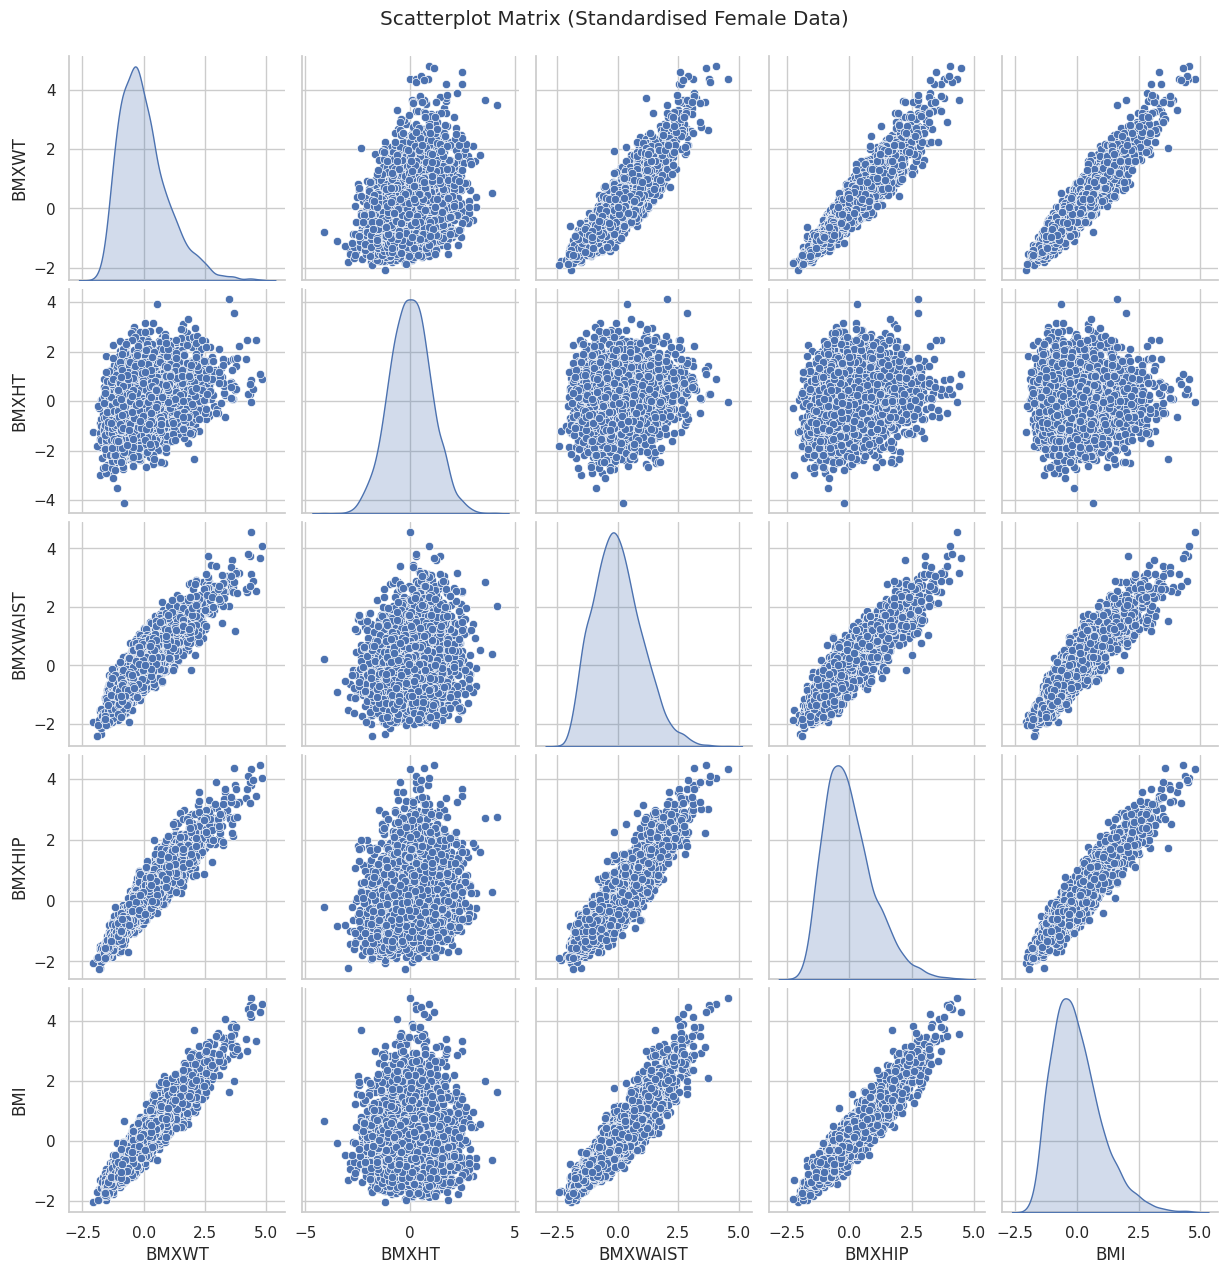

Pearson Correlation:
              BMXWT     BMXHT  BMXWAIST    BMXHIP       BMI
BMXWT     1.000000  0.345496  0.904550  0.946553  0.945900
BMXHT     0.345496  1.000000  0.126547  0.202895  0.033077
BMXWAIST  0.904550  0.126547  1.000000  0.897407  0.921198
BMXHIP    0.946553  0.202895  0.897407  1.000000  0.944199
BMI       0.945900  0.033077  0.921198  0.944199  1.000000

Spearman Correlation:
              BMXWT     BMXHT  BMXWAIST    BMXHIP       BMI
BMXWT     1.000000  0.338860  0.900169  0.946634  0.937999
BMXHT     0.338860  1.000000  0.108587  0.205405  0.019897
BMXWAIST  0.900169  0.108587  1.000000  0.888037  0.923114
BMXHIP    0.946634  0.205405  0.888037  1.000000  0.934196
BMI       0.937999  0.019897  0.923114  0.934196  1.000000


In [ ]:
# Select relevant columns
cols = ["BMXWT", "BMXHT", "BMXWAIST", "BMXHIP", "BMI"]
df_zfemale = zfemale[cols].copy()

sns.pairplot(df_zfemale, diag_kind="kde")
plt.suptitle("Scatterplot Matrix (Standardised Female Data)", y=1.02)
plt.show()

# Pearson and Spearman correlations
pear_corr = df_zfemale.corr(method="pearson")
spear_corr = df_zfemale.corr(method="spearman")

print("Pearson Correlation:\n", pear_corr)
print("\nSpearman Correlation:\n", spear_corr)


***Explanation:***
1. Selects key variables & uses standardized female data (zfemale) for consistent scaling.
2. Creates a scatterplot matrix to show pairwise relationships between variables.
3. diag_kind="kde" plots kernel density estimates on the diagonal to show data spread, skewness & peaks for each variable.
4. Computes correlation matrices:
* **Pearson correlation:** measures linear relationships between variables. Values range from -1 to +1:
    * +1 - perfect positive linear correlation.
    * -1 - perfect negative linear correlation.
    * 0 - no linear correlation.
* **Spearman correlation:** measures monotonic relationships, capturing non-linear trends. Less sensitive to outliers than Pearson correlation. Values range from -1 to +1 (similar interpretations as Pearson).
5. Displays correlation matrices numerically for interpretation.

***Insights:***
1. **Positive Relationships:** Weight, waist, hip & BMI tend to increase together, visible from the upward trends in scatterplots.
2. **Height Relationship:** Height shows less clear association with weight or BMI compared to other body measures.
3. **Data Spread & Clusters:** Most points are concentrated in a central cluster, with a few scattered points indicating potential outliers.
4. **Distribution Shapes (KDE plots):**
* Weight, waist, hip & BMI distributions - slightly right-skewed.
* Height distribution - more symmetric.
5. **Outliers:** Few points far from main clusters indicate extreme values, especially in weight, waist, hip or BMI.
6. Standing Height has weaker correlations with waist, hip & BMI compared to the correlations of weight with these variables - suggests that while height contributes to weight & BMI, waist & hip measurements have a stronger linear and monotonic relationship with weight and BMI for females in this dataset.
7. Both Pearson and Spearman correlations show similar patterns - relationships are largely linear for these variables.

# Compute Waist-to-Height and Waist-to-Hip Ratios

In [ ]:
female_df["Waist_Height"] = female_df["BMXWAIST"] / female_df["BMXHT"]
female_df["Waist_Hip"] = female_df["BMXWAIST"] / female_df["BMXHIP"]

male_df["Waist_Height"] = male_df["BMXWAIST"] / male_df["BMXHT"]
male_df["Waist_Hip"] = male_df["BMXWAIST"] / male_df["BMXHIP"]


1. Waist-to-Height Ratio (WHtR) & Waist-to-Hip Ratio (WHR) are computed for both female & male datasets & added as new columns.
2. Ratios provide standardized measures of body fat distribution, useful for assessing health risk.
3. **Health Indicators:** Higher Waist-to-Height or Waist-to-Hip ratios indicate greater central adiposity, linked to cardiometabolic risk.
4. **Gender Differences:** Females & males may show different average ratios, reflecting typical fat distribution patterns (e.g., males more abdominal, females more hip-centered).
5. This helps us for further BMI & fat distribution analysis.

# Boxplot of Waist Ratios with Risk Thresholds

/tmp/ipython-input-3941399000.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


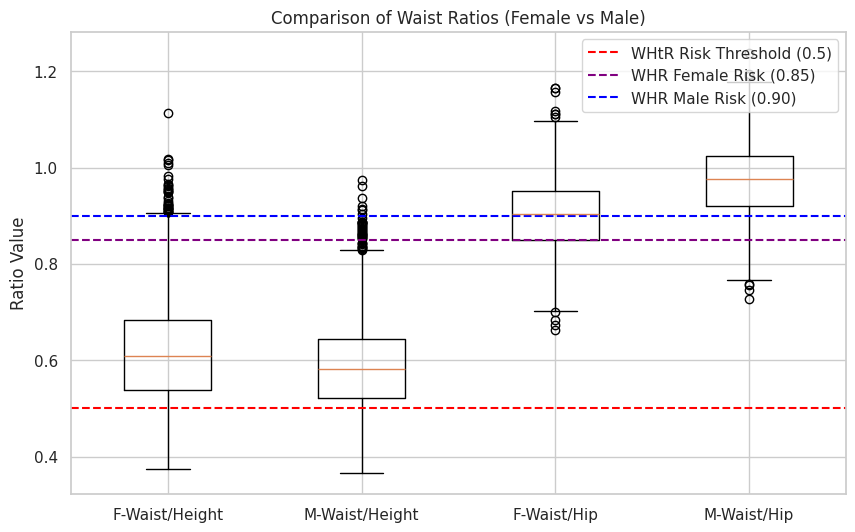


Summary Statistics for Ratios:

       Female Waist/Height  Male Waist/Height  Female Waist/Hip  \
count          4221.000000        4081.000000       4221.000000   
mean              0.615617           0.585983          0.899979   
std               0.108043           0.093693          0.072258   
min               0.375074           0.366152          0.662742   
25%               0.537455           0.521549          0.850643   
50%               0.609741           0.581917          0.902887   
75%               0.684505           0.644682          0.951529   
max               1.113196           0.973774          1.165263   

       Male Waist/Hip  
count     4081.000000  
mean         0.970844  
std          0.077280  
min          0.726231  
25%          0.919278  
50%          0.976720  
75%          1.024679  
max          1.238372  


In [ ]:
plt.figure(figsize=(10,6))

# Boxplot
plt.boxplot([
    female_df["Waist_Height"],
    male_df["Waist_Height"],
    female_df["Waist_Hip"],
    male_df["Waist_Hip"]
],
labels=["F-Waist/Height", "M-Waist/Height",
        "F-Waist/Hip", "M-Waist/Hip"])

plt.title("Comparison of Waist Ratios (Female vs Male)")
plt.ylabel("Ratio Value")

# Add Reference Lines
# Waist-to-Height Risk (same for both sexes)
plt.axhline(0.5, color="red", linestyle="--", label="WHtR Risk Threshold (0.5)")

# Waist-to-Hip Risk (sex-specific)
plt.axhline(0.85, color="purple", linestyle="--", label="WHR Female Risk (0.85)")
plt.axhline(0.90, color="blue", linestyle="--", label="WHR Male Risk (0.90)")

plt.legend(loc="upper right")
plt.show()

# Summary Statistics
ratio_stats = pd.DataFrame({
    "Female Waist/Height": female_df["Waist_Height"].describe(),
    "Male Waist/Height": male_df["Waist_Height"].describe(),
    "Female Waist/Hip": female_df["Waist_Hip"].describe(),
    "Male Waist/Hip": male_df["Waist_Hip"].describe()
})

print("\nSummary Statistics for Ratios:\n")
print(ratio_stats)


***Explanation:***
1. Creates boxplot comparing Waist-to-Height (WHtR) & Waist-to-Hip (WHR) ratios for females & males.
2. **Adds risk threshold lines:**
* WHtR ≥ 0.5 - increased health risk for both sexes.
* WHR ≥ 0.85 (female) or ≥ 0.90 (male) - elevated cardiometabolic risk.
3. Shows numeric distribution statistics for each ratio.

***Insights:***
1. **Median Comparison:**
* Male WHtR median > female WHtR (slightly) - males may have higher central adiposity.
* Females WHR < males WHR (WHR medians reflect typical fat distribution differences).
2. **Spread and Variability:**
* WHtR shows less variability than WHR in both sexes.
* WHR for males shows a slightly wider range, suggesting more diverse fat distribution patterns.
3. **Outliers:** Points outside whiskers - individuals with extreme ratios, potentially at higher health risk.
4. **Threshold Comparison:** Few female and male WHtR or WHR values exceed the risk thresholds, highlighting individuals at increased cardiometabolic risk.
5. **Gender Differences:** Males generally have higher WHtR and WHR compared to females.

# Compare Lowest vs. Highest BMI (Females)

In [ ]:
lowest_idx = female_df["BMI"].nsmallest(5).index
highest_idx = female_df["BMI"].nlargest(5).index

# Extract rows from zfemale
lowest = zfemale.loc[lowest_idx].copy()
highest = zfemale.loc[highest_idx].copy()

# Add labels
lowest["Group"] = "Lowest BMI"
highest["Group"] = "Highest BMI"

# Combine into one DataFrame
selected = pd.concat([lowest, highest])

# Round for readability
selected_rounded = selected.round(2)

print("Standardised measurements for 5 lowest + 5 highest BMI females:\n")
display(selected_rounded)

Standardised measurements for 5 lowest + 5 highest BMI females:



,BMXWT,BMXHT,BMXARML,BMXLEG,BMXARMC,BMXHIP,BMXWAIST,BMI,Group
262,-2.08,-1.22,-1.55,-1.17,-2.19,-2.04,-1.94,-2.05,Lowest BMI
3478,-1.88,-0.19,-1.72,0.39,-2.44,-1.85,-2.06,-1.99,Lowest BMI
2126,-1.54,1.81,0.63,0.57,-2.27,-1.68,-1.71,-1.97,Lowest BMI
2753,-1.84,-0.26,-0.23,0.51,-2.30,-2.25,-1.86,-1.94,Lowest BMI
1209,-1.61,0.89,-0.10,0.48,-2.21,-1.83,-1.71,-1.89,Lowest BMI
1096,4.36,-0.03,-0.06,-0.17,2.78,4.32,4.57,4.76,Highest BMI
1104,4.80,0.89,2.12,1.82,3.78,4.02,4.08,4.54,Highest BMI
1472,4.35,0.28,2.84,1.94,4.37,3.92,3.75,4.51,Highest BMI
3022,4.46,0.50,1.69,-1.14,3.35,3.98,2.90,4.46,Highest BMI
2268,4.25,0.29,1.86,-0.98,2.37,4.10,3.82,4.40,Highest BMI


***Explanation:***
1. Identifies 5 females with lowest BMI & 5 with highest BMI.
2. Extracts their standardized measurements from the zfemale dataset.
3. Adds a label column (Group) to indicate whether each row belongs to “Lowest BMI” or “Highest BMI.”
4. Combines both groups into a single DataFrame and rounds values for readability.
5. Presents a clear table of standardized body measurements.

***Insights:***
1. Highest BMI - higher standardized weight, waist, hip & BMI scores.
2. Lowest BMI - lower standardized measurements.

# Insight on some parameters used

1. ***BMI:***
* **Advantage:** Simple, widely used, easy to compute
* **Disadvantage:** Doesn’t account for fat distribution or muscle mass

2. ***Waist-to-Height Ratio:***
* **Advantage:** Strong predictor of metabolic risk, adjusts for height
* **Disadvantage:** Less common in practice

3. ***Waist-to-Hip Ratio***
* **Advantage:** Shows fat distribution (central vs peripheral obesity)
* **Disadvantage:** Hip measurement can be inconsistent

# References

- Centers for Disease Control and Prevention (CDC). National Health and Nutrition Examination Survey (NHANES).
Available at: https://www.cdc.gov/nchs/nhanes/
- Keys, A., Fidanza, F., Karvonen, M. J., Kimura, N., & Taylor, H. L. (1972). Indices of relative weight and obesity. Journal of Chronic Diseases, 25(6–7), 329–343. (Original BMI reference)
- Ashwell, M., & Gibson, S. (2016). Waist-to-height ratio as an indicator of ‘early health risk’: simpler and more predictive than BMI. BMJ Open, 6(3), e010159.
- World Health Organization (WHO). (2008). Waist Circumference and Waist–Hip Ratio: Report of a WHO Expert Consultation. Geneva: WHO.
- Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming with NumPy. Nature, 585, 357–362.
- Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. Computing in Science & Engineering, 9(3), 90–95.
- Waskom, M. L. (2021). Seaborn: Statistical Data Visualization. Journal of Open Source Software, 6(60), 3021.
- Virtanen, P., Gommers, R., Oliphant, T. E., et al. (2020). SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. Nature Methods, 17, 261–272.
